# Import Libs

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB

from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

import joblib

import warnings
warnings.filterwarnings('ignore')

# Read Data

In [2]:
true = pd.read_csv('true.csv')
true['label'] = 1
fake = pd.read_csv('fake.csv')
fake['label'] = 0

df = pd.concat([true, fake], axis=0)
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

In [6]:
df.head()

,title,text,subject,date,label
0,BREAKING: GOP Chairman Grassley Has Had Enoug...,"Donald Trump s White House is in chaos, and th...",News,"July 21, 2017",0
1,Failed GOP Candidates Remembered In Hilarious...,Now that Donald Trump is the presumptive GOP n...,News,"May 7, 2016",0
2,Mike Pence’s New DC Neighbors Are HILARIOUSLY...,Mike Pence is a huge homophobe. He supports ex...,News,"December 3, 2016",0
3,California AG pledges to defend birth control ...,SAN FRANCISCO (Reuters) - California Attorney ...,politicsNews,"October 6, 2017",1
4,AZ RANCHERS Living On US-Mexico Border Destroy...,Twisted reasoning is all that comes from Pelos...,politics,"Apr 25, 2017",0


# Understand Data

In [4]:
df.shape

(44898, 5)

In [5]:
df.columns

Index(['title', 'text', 'subject', 'date', 'label'], dtype='str')

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 44898 entries, 0 to 44897
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   title    44898 non-null  str  
 1   text     44898 non-null  str  
 2   subject  44898 non-null  str  
 3   date     44898 non-null  str  
 4   label    44898 non-null  int64
dtypes: int64(1), str(4)
memory usage: 112.3 MB


In [9]:
df.describe(include='all')

,title,text,subject,date,label
count,44898,44898,44898,44898,44898.000000
unique,38729,38646,8,2397,NaN
top,Factbox: Trump fills top jobs for his administ...,,politicsNews,"December 20, 2017",NaN
freq,14,627,11272,182,NaN
mean,NaN,NaN,NaN,NaN,0.477015
std,NaN,NaN,NaN,NaN,0.499477
min,NaN,NaN,NaN,NaN,0.000000
25%,NaN,NaN,NaN,NaN,0.000000
50%,NaN,NaN,NaN,NaN,0.000000
75%,NaN,NaN,NaN,NaN,1.000000


# Data Cleaning

In [11]:
print(f'Duplicates: {df.duplicated().sum()}')
df.drop_duplicates(inplace=True)
print(f'Duplicates: {df.duplicated().sum()}')

Duplicates: 209
Duplicates: 0


In [12]:
print(f'Nulls:\n{df.isnull().sum()}')

Nulls:
title      0
text       0
subject    0
date       0
label      0
dtype: int64


In [13]:
df.drop('date', axis=1, inplace=True)

In [24]:
df['subject'] = df['subject'].str.strip().str.lower()
df['title'] = df['title'].str.strip().str.lower()
df['text'] = df['text'].str.strip().str.lower()
df['text_length'] = df['text'].apply(len)

In [20]:
df['subject'] = df['subject'].replace({
    'politics': 'politicsnews',
    'government news': 'worldnews',
    'us_news': 'worldnews',
    'middle-east': 'worldnews'
})

# SDA

In [23]:
df['subject'].value_counts(normalize=True)*100

subject
politicsnews    40.408154
worldnews       29.362930
news            20.251068
left-news        9.977847
Name: proportion, dtype: float64

In [25]:
df['text_length'].describe()

count    44689.000000
mean      2466.277921
std       2173.645538
min          0.000000
25%       1232.000000
50%       2184.000000
75%       3101.000000
max      51793.000000
Name: text_length, dtype: float64

In [26]:
df.groupby('subject')['text_length'].describe()

,count,mean,std,min,25%,50%,75%,max
subject,,,,,,,,
left-news,4459.0,2370.555057,2258.766790,0.0,1118.00,1924.0,3053.0,49704.0
news,9050.0,2622.893591,966.103927,260.0,2031.25,2426.0,3009.0,26734.0
politicsnews,18058.0,2370.433714,1990.417503,0.0,825.25,2120.0,3224.0,49704.0
worldnews,13122.0,2522.687852,2868.190936,0.0,952.25,1966.0,3108.0,51793.0


In [21]:
Label_Subject = df.groupby('label')['subject'].value_counts().sort_values(ascending=False)
Label_Subject

label  subject     
1      politicsnews    11220
       worldnews        9991
0      news             9050
       politicsnews     6838
       left-news        4459
       worldnews        3131
Name: count, dtype: int64

# EDA

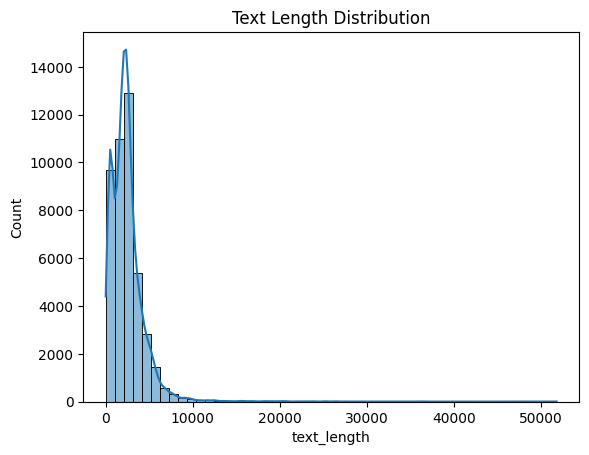

In [27]:
sns.histplot(df['text_length'], bins=50, kde=True)
plt.title("Text Length Distribution")
plt.show()

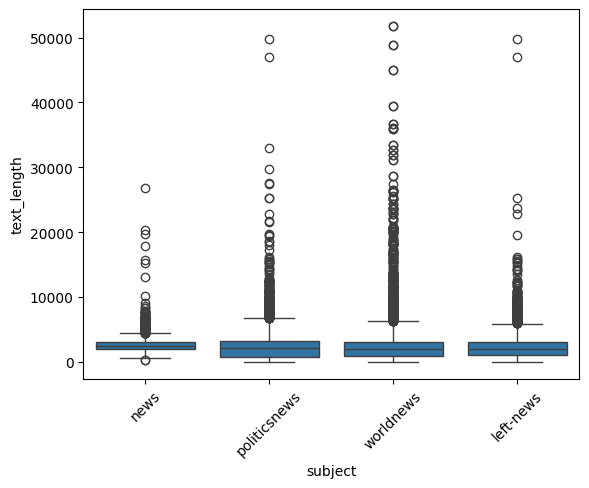

In [28]:
sns.boxplot(data=df, x='subject', y='text_length')
plt.xticks(rotation=45)
plt.show()

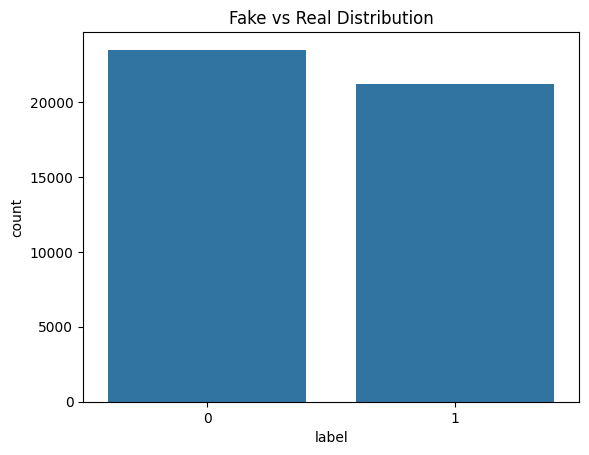

In [29]:
sns.countplot(data=df, x='label')
plt.title("Fake vs Real Distribution")
plt.show()

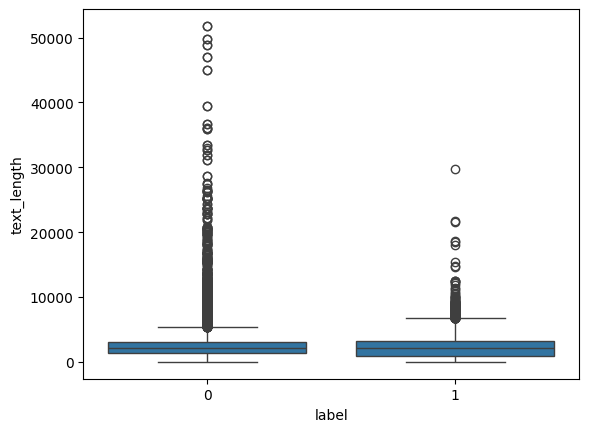

In [30]:
sns.boxplot(data=df, x='label', y='text_length')
plt.show()

# Data Spliting

In [45]:
x = df['text']
y = df['label']

xtrain, xtest, ytrain, ytest = train_test_split(x, y,
                                               random_state=42,
                                               test_size=0.3,
                                               stratify=y)

# Preprocessor

In [46]:
tfidf = TfidfVectorizer(
    ngram_range=(1,2),
    min_df=0.2,
    max_df=0.95,
    max_features=5000
)

# Model Comparison

Dummy model Training
Score: [0.52533163 0.52533163 0.52525575 0.5254156  0.5254156 ]
Mean Accuracy: 0.5253500427347457
Accuracy: 0.5254
Report:
              precision    recall  f1-score   support

           0       0.53      1.00      0.69      7044
           1       0.00      0.00      0.00      6363

    accuracy                           0.53     13407
   macro avg       0.26      0.50      0.34     13407
weighted avg       0.28      0.53      0.36     13407



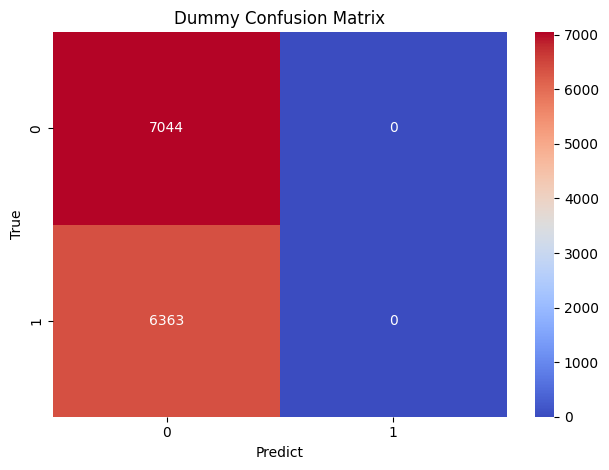

Logistic model Training
Score: [0.98162058 0.98050184 0.98113811 0.98081841 0.98049872]
Mean Accuracy: 0.9809155331706239
Accuracy: 0.9796
Report:
              precision    recall  f1-score   support

           0       0.98      0.98      0.98      7044
           1       0.98      0.98      0.98      6363

    accuracy                           0.98     13407
   macro avg       0.98      0.98      0.98     13407
weighted avg       0.98      0.98      0.98     13407



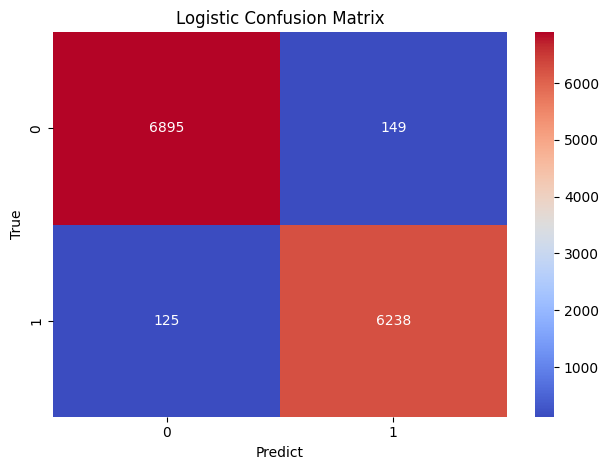

SVM model Training
Score: [0.99136967 0.99041074 0.99216752 0.99008951 0.98976982]
Mean Accuracy: 0.9907614520330581
Accuracy: 0.9889
Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      7044
           1       0.99      0.99      0.99      6363

    accuracy                           0.99     13407
   macro avg       0.99      0.99      0.99     13407
weighted avg       0.99      0.99      0.99     13407



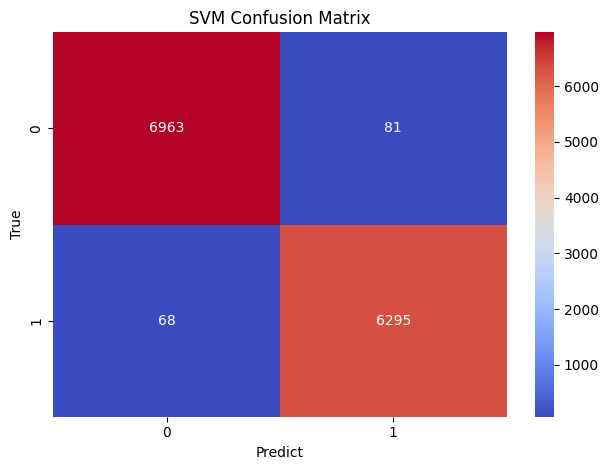

NB model Training
Score: [0.93431357 0.94134569 0.93909847 0.93973785 0.93430307]
Mean Accuracy: 0.9377597295632473
Accuracy: 0.9347
Report:
              precision    recall  f1-score   support

           0       0.95      0.93      0.94      7044
           1       0.92      0.94      0.93      6363

    accuracy                           0.93     13407
   macro avg       0.93      0.94      0.93     13407
weighted avg       0.93      0.93      0.93     13407



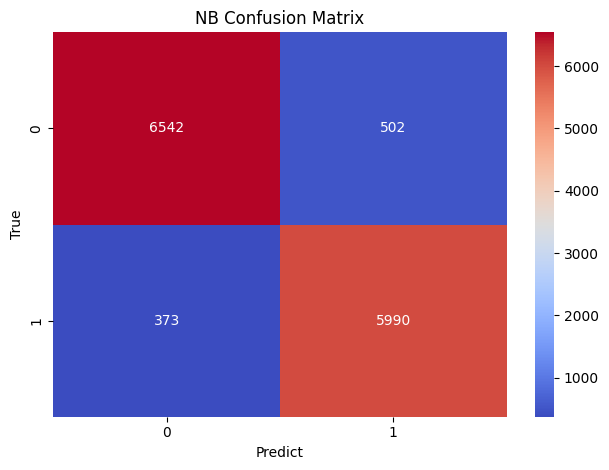

['pipeline.pkl']

In [47]:
models = {
    'Dummy':DummyClassifier(),
    'Logistic':LogisticRegression(class_weight='balanced'),
    'SVM':LinearSVC(class_weight='balanced'),
    'NB':MultinomialNB()
}

best_score = 0
best_model = None
best_model_name = ''

for name, model in models.items():
    pipe = Pipeline([
        ('Tfidf', tfidf),
        ('clf', model)
    ])

    pipe.fit(xtrain, ytrain)
    y_pred = pipe.predict(xtest)

    scores = cross_val_score(pipe, xtrain, ytrain, scoring='accuracy')

    acc = accuracy_score(ytest, y_pred)
    cr = classification_report(ytest, y_pred)
    cm = confusion_matrix(ytest, y_pred)
    print(f'{name} model Training')
    print(f'Score: {scores}')
    print(f'Mean Accuracy: {scores.mean()}')
    print(f'Accuracy: {acc:0.4f}')
    print(f'Report:\n{cr}')
    sns.heatmap(cm, annot=True, fmt='d', cmap='coolwarm')
    plt.title(f'{name} Confusion Matrix')
    plt.ylabel('True')
    plt.xlabel('Predict')
    plt.tight_layout()
    plt.show()
    print('='*60)

    if acc > best_score:
        best_score = acc
        best_model_name = name
        best_model = model

joblib.dump(pipe, 'pipeline.pkl')